This dataset was found via Kaggle.com, with the intended goal of the project being the capability of detecting fradulent transactions throughout a vast dataset of transactions completed in September 2013 by European cardholders.

"*This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.*"

UCI_Link = "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download"

Google_Drive_Sharelink = "https://drive.google.com/file/d/1dWjvgNGVXS6xX7AUCGvzbg0ksCUPaVcO/view?usp=drive_link"

**Helper Functions**

In [1]:
# =========================================================
# Helper functions
# =========================================================

def _is_torch_tensor(x):
    try:
        import torch
        return torch.is_tensor(x)
    except ImportError:
        return False


def _torch_take(x, indices):
    import torch
    idx = torch.as_tensor(indices, dtype=torch.long, device=x.device)
    return x.index_select(0, idx)


def _take(x, indices):
    """
    Index x along axis 0 while preserving input type.
    """
    if _is_torch_tensor(x):
        return _torch_take(x, indices)

    if isinstance(x, np.ndarray):
        return x[indices]

    if isinstance(x, list):
        return [x[int(i)] for i in indices]

    if isinstance(x, tuple):
        return tuple(x[int(i)] for i in indices)

    arr = np.asarray(x)
    return arr[indices]


# =========================================================
# XY train/test split
# =========================================================

def xy_test_train_split(X, y, test_size=0.2, random_state=None):
    """
    Simple sklearn-like train/test split for X and y only.

    Parameters
    ----------
    X, y : list | tuple | np.ndarray | torch.Tensor
    test_size : float, default=0.2
    random_state : int or None

    Returns
    -------
    X_train, X_test, y_train, y_test
    """
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of samples")

    if not (0.0 < float(test_size) < 1.0):
        raise ValueError("test_size must be a float in (0, 1)")

    n_samples = len(X)
    n_test = int(np.ceil(n_samples * float(test_size)))

    rng = np.random.RandomState(random_state)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    X_train = _take(X, train_idx)
    X_test = _take(X, test_idx)
    y_train = _take(y, train_idx)
    y_test = _take(y, test_idx)

    return X_train, X_test, y_train, y_test


# =========================================================
# StandardScaler
# =========================================================

class StandardScaler:
    """
    Simple implementation of sklearn.preprocessing.StandardScaler.

    Standardizes features by removing the mean and scaling to unit variance:
        z = (x - mean) / std

    Uses population standard deviation (ddof=0), same as sklearn.
    """

    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        if _is_torch_tensor(X):
            import torch
            self.mean_ = X.mean(dim=0)
            self.scale_ = X.std(dim=0, unbiased=False)
            self.scale_ = torch.where(
                self.scale_ == 0,
                torch.ones_like(self.scale_),
                self.scale_,
            )
            return self

        X_np = np.asarray(X, dtype=float)
        self.mean_ = X_np.mean(axis=0)
        self.scale_ = X_np.std(axis=0)
        self.scale_[self.scale_ == 0] = 1.0
        return self

    def transform(self, X):
        if self.mean_ is None or self.scale_ is None:
            raise RuntimeError("StandardScaler has not been fitted yet")

        if _is_torch_tensor(X):
            return (X - self.mean_) / self.scale_

        X_np = np.asarray(X, dtype=float)
        return (X_np - self.mean_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        if self.mean_ is None or self.scale_ is None:
            raise RuntimeError("StandardScaler has not been fitted yet")

        if _is_torch_tensor(X):
            return X * self.scale_ + self.mean_

        X_np = np.asarray(X, dtype=float)
        return X_np * self.scale_ + self.mean_


# =========================================================
# Convenience helper
# =========================================================

def scale_train_test(X_train, X_test):
    """
    Fit a StandardScaler on X_train, then transform both X_train and X_test.

    Returns
    -------
    X_train_scaled, X_test_scaled, scaler
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


# =========================================================
# Public API
# =========================================================

__all__ = [
    "xy_test_train_split",
    "StandardScaler",
    "scale_train_test",
]

**Imports**


In [2]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

**Loading Dataset**

In [3]:

file_id = "1dWjvgNGVXS6xX7AUCGvzbg0ksCUPaVcO"
URL = f"https://drive.google.com/uc?id={file_id}"

output = "creditcard.csv"

gdown.download(URL, output, quiet=False)

df = pd.read_csv(output)

print(df.shape)
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1dWjvgNGVXS6xX7AUCGvzbg0ksCUPaVcO
From (redirected): https://drive.google.com/uc?id=1dWjvgNGVXS6xX7AUCGvzbg0ksCUPaVcO&confirm=t&uuid=e67d8eda-b892-499d-b56e-acbe4c678c9a
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:02<00:00, 51.6MB/s]


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Pre-processing functions**

In [4]:
x_df = df.drop(columns=["Class"])
y = df["Class"].to_numpy(dtype=np.int64)
x = x_df.to_numpy(dtype=np.float32)

print("x shape: ", x.shape)
print("y shape: ", y.shape)
print("Normal Transaction Count: ",np.sum(y==0))
print("Fraud Transaction Count: ",np.sum(y==1))

x_train, x_test, y_train, y_test = xy_test_train_split(x, y, test_size=0.2, random_state=42)

x_train_scaled, x_test_scaled, scaler = scale_train_test(x_train, x_test)
print("Training Size: ",x_train.shape)
print("Test Size: ",x_test.shape)

x shape:  (284807, 30)
y shape:  (284807,)
Normal Transaction Count:  284315
Fraud Transaction Count:  492
Training Size:  (227845, 30)
Test Size:  (56962, 30)


The above dataset shape tells us that there are:

284,807 rows --> Transactions

31 Columns --> Features + Label

Columns = 30 input features, and 1 target label.

**Converting to PyTorch**

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32).to(device)
x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)

y_train_t_bin = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)
y_test_t_bin = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32).to(device)

y_train_t_cls = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t_cls = torch.tensor(y_test, dtype=torch.long).to(device)

n_features = x_train_t.shape[1]

print("x_train_t shape: ", x_train_t.shape)
print("x_test_t shape: ",x_test_t.shape)
print("Number of features: ", n_features)

x_train_t shape:  torch.Size([227845, 30])
x_test_t shape:  torch.Size([56962, 30])
Number of features:  30


**Logistic Regression Model**

In [10]:
class LogisticRegression(torch.nn.Module):
  def __init__(self, n_input_features):
    super(LogisticRegression, self).__init__()
    self.linear = torch.nn.Linear(n_input_features, 1)

  def forward(self, x):
    y_predicted = torch.sigmoid(self.linear(x))
    return y_predicted

model = LogisticRegression(n_features).to(device)
learning_rate = 0.05

criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

num_epochs = 300
loss_history_lr = []

for epoch in range(num_epochs):
  y_predicted = model(x_train_t)
  loss = criterion(y_predicted, y_train_t_bin)

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

  loss_history_lr.append(loss.item())

  if (epoch + 1) % 10 == 0:
    print(f'Epoch {epoch+1}, Loss = {loss.item():.4f}')

with torch.no_grad():
  y_predicted = model(x_test_t)
  y_predicted_cls = y_predicted.round()
  acc = y_predicted_cls.eq(y_test_t_bin).sum() / float(y_test_t_bin.shape[0])

  print(f'\nLogistic Regression Test Accuracy = {acc:.4f}')


Epoch 10, Loss = 0.5566
Epoch 20, Loss = 0.4752
Epoch 30, Loss = 0.4105
Epoch 40, Loss = 0.3588
Epoch 50, Loss = 0.3169
Epoch 60, Loss = 0.2827
Epoch 70, Loss = 0.2544
Epoch 80, Loss = 0.2308
Epoch 90, Loss = 0.2109
Epoch 100, Loss = 0.1939
Epoch 110, Loss = 0.1793
Epoch 120, Loss = 0.1667
Epoch 130, Loss = 0.1556
Epoch 140, Loss = 0.1459
Epoch 150, Loss = 0.1372
Epoch 160, Loss = 0.1295
Epoch 170, Loss = 0.1226
Epoch 180, Loss = 0.1164
Epoch 190, Loss = 0.1108
Epoch 200, Loss = 0.1057
Epoch 210, Loss = 0.1010
Epoch 220, Loss = 0.0967
Epoch 230, Loss = 0.0928
Epoch 240, Loss = 0.0891
Epoch 250, Loss = 0.0858
Epoch 260, Loss = 0.0827
Epoch 270, Loss = 0.0798
Epoch 280, Loss = 0.0771
Epoch 290, Loss = 0.0746
Epoch 300, Loss = 0.0722

Logistic Regression Test Accuracy = 0.9991


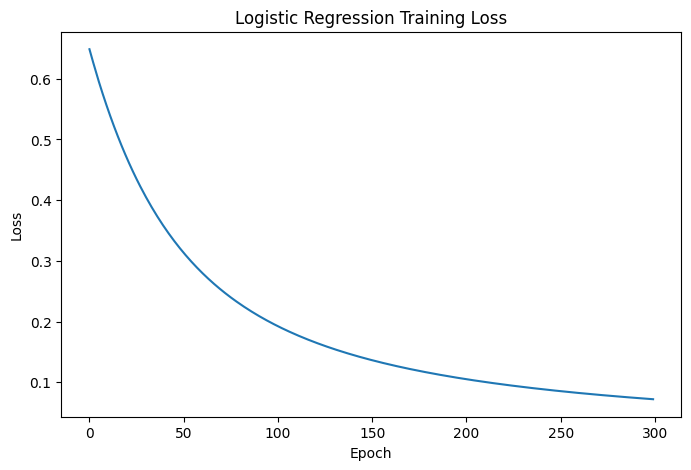

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_lr)
plt.title("Logistic Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**Neural Network Model**

In [12]:
train_ds = TensorDataset(x_train_t, y_train_t_bin)
test_ds = TensorDataset(x_test_t, y_test_t_bin)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

class NeuralNetwork(torch.nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.model = torch.nn.Sequential(
        torch.nn.Linear(input_dim, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.model(x)

model_nn = NeuralNetwork(input_dim=n_features).to(device)

criterion_nn = torch.nn.BCEWithLogitsLoss()
optimizer_nn = torch.optim.Adam(model_nn.parameters(), lr=0.001)

epochs = 20
loss_history = []

for epoch in range(epochs):
  model_nn.train()
  total_loss = 0.0

  for xb, yb in train_loader:
    xb, yb = xb.to(device), yb.to(device)

    logits = model_nn(xb)
    loss = criterion_nn(logits, yb)
    optimizer_nn.zero_grad()
    loss.backward()
    optimizer_nn.step()

    total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
  loss_history.append(avg_loss)

  print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f}")

model_nn.eval()
tp = 0
tn = 0
fp = 0
fn = 0

with torch.no_grad():
  for xb, yb in test_loader:
      xb, yb = xb.to(device), yb.to(device)

      logits = model_nn(xb)
      probs = torch.sigmoid(logits)
      preds = (probs >= 0.5).float()

      tp += ((preds==1) & (yb==1)).sum().item()
      tn += ((preds==0) & (yb==0)).sum().item()
      fp += ((preds==1) & (yb==0)).sum().item()
      fn += ((preds==0) & (yb==1)).sum().item()

total = tp + tn + fp + fn

accuracy = (tp + tn) / total
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("\nNeural Network Final Results")
print(f"Accuracy = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall = {recall:.4f}")
print(f"F1 Score = {f1_score:.4f}")

print("\nConfusion Matrix Counts")
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")


Epoch 01 | Loss: 0.0277
Epoch 02 | Loss: 0.0033
Epoch 03 | Loss: 0.0029
Epoch 04 | Loss: 0.0026
Epoch 05 | Loss: 0.0024
Epoch 06 | Loss: 0.0023
Epoch 07 | Loss: 0.0022
Epoch 08 | Loss: 0.0021
Epoch 09 | Loss: 0.0020
Epoch 10 | Loss: 0.0019
Epoch 11 | Loss: 0.0018
Epoch 12 | Loss: 0.0017
Epoch 13 | Loss: 0.0017
Epoch 14 | Loss: 0.0016
Epoch 15 | Loss: 0.0015
Epoch 16 | Loss: 0.0015
Epoch 17 | Loss: 0.0014
Epoch 18 | Loss: 0.0013
Epoch 19 | Loss: 0.0013
Epoch 20 | Loss: 0.0012

Neural Network Final Results
Accuracy = 0.9994
Precision = 0.8810
Recall = 0.7551
F1 Score = 0.8132

Confusion Matrix Counts
True Positives (TP): 74
True Negatives (TN): 56854
False Positives (FP): 10
False Negatives (FN): 24


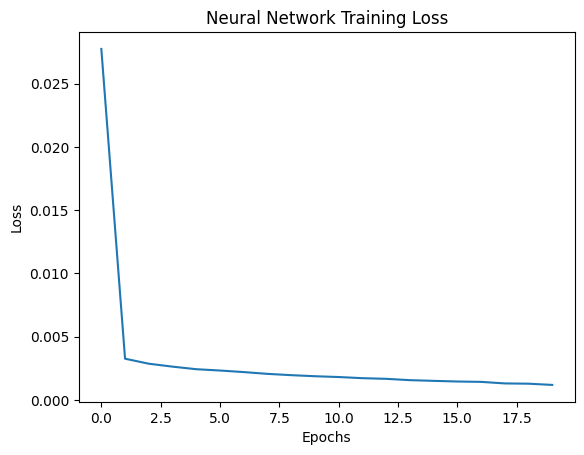

In [13]:
plt.plot(loss_history)
plt.title("Neural Network Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()